# Data Drift: Zero to Hero
## A Complete Practical Notebook for ML Engineers

**What you will master after this notebook:**
- What data drift is, formally and intuitively, with proofs
- The 3 fundamental types of drift and how they differ mathematically
- Every major statistical detection method implemented from scratch with visualizations
- Rolling production monitoring over time windows
- Mitigation with importance weighting and automated retraining triggers
- A production-ready `DriftMonitor` class you can paste into any ML project

---

> **Scenario used throughout:** You trained a credit-risk default prediction model on 2020 data and deployed it to production. Users change. Economy shifts. Fraud patterns evolve. This notebook teaches you to catch all of that before the model costs money.

---

**Contents:**
1. Setup & Synthetic Dataset
2. What Is Data Drift? (Formal Definition)
3. Types of Drift (Covariate / Label / Concept)
4. Statistical Detection: KS Test
5. Statistical Detection: PSI
6. Statistical Detection: Chi-Squared (Categorical)
7. Statistical Detection: MMD (Multivariate)
8. Statistical Detection: ADWIN (Streaming)
9. Multiple Testing Correction
10. Rolling Production Monitoring
11. Evidently AI (Production Tool)
12. Mitigation Strategies
13. Production-Ready DriftMonitor Class
14. Summary & Decision Guide


## Section 0 — Setup

All code in this notebook requires only standard ML libraries. Evidently AI is optional and only used in Section 11.

In [1]:
# Uncomment to install if needed
# !pip install numpy pandas matplotlib seaborn scipy scikit-learn evidently -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from scipy.special import expit            # sigmoid function
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

BLUE   = '#1658A0'
RED    = '#B93228'
GREEN  = '#1E9650'
ORANGE = '#C86400'
GRAY   = '#888888'

print('Setup complete. All libraries loaded.')


Setup complete. All libraries loaded.


## Section 1 — Synthetic Dataset: The Credit Risk Scenario

We generate realistic synthetic data for a **credit default prediction** problem.

**Features:**
- `age` — borrower age (continuous)
- `income` — annual income in USD, log-normal (continuous)
- `credit_score` — FICO score 300–850 (continuous)
- `loan_amount` — requested loan amount (continuous)
- `employ_years` — years at current employer (continuous)
- `region` — geographic region (categorical)

**Target:** `default` — 1 if the borrower defaulted, 0 otherwise

**Default probability formula (true DGP):**
$$P(Y=1|X) = \sigma\left(-0.02(\text{credit\_score}-680) - 0.8\ln\frac{\text{income}}{\mu_{inc}} + 0.03\frac{\text{loan}}{\text{income}} - 0.05\cdot\text{employ\_years}\right)$$

We generate 4 dataset variants to simulate different drift types:

| Mode | What changes | What stays same |
|------|-------------|------------------|
| `reference` | — | baseline |
| `covariate` | P(X) | P(Y\|X) |
| `label` | P(Y) | P(X\|Y) |
| `concept` | P(Y\|X) | P(X) |


In [2]:
def generate_data(n=2000, seed=42, mode='reference'):
    """
    Synthetic credit-risk data generator.
    mode: 'reference' | 'covariate' | 'label' | 'concept'
    """
    rng = np.random.RandomState(seed)
    REF_INCOME_LOG = 10.5  # reference log-mean of income

    if mode == 'reference':
        age          = rng.normal(42, 12, n).clip(18, 80).astype(int)
        income       = rng.lognormal(10.5, 0.5, n)
        credit_score = rng.normal(680, 80, n).clip(300, 850).astype(int)
        loan_amount  = rng.lognormal(10.2, 0.6, n)
        employ_years = rng.exponential(7, n).clip(0, 40)
        region       = rng.choice(['North','South','East','West'], n, p=[0.30,0.25,0.25,0.20])
        logit = (- 0.020 * (credit_score - 680)
                 - 0.800 * np.log(income / np.exp(REF_INCOME_LOG))
                 + 0.030 * (loan_amount / income)
                 - 0.050 * employ_years
                 + 0.010 * np.maximum(0, 45 - age))

    elif mode == 'covariate':
        # P(X) shifts: gig economy — younger, lower income, shorter tenure
        # P(Y|X) is IDENTICAL — same logit formula
        age          = rng.normal(35, 14, n).clip(18, 80).astype(int)
        income       = rng.lognormal(10.1, 0.75, n)   # lower mean, higher variance
        credit_score = rng.normal(650, 95,  n).clip(300, 850).astype(int)
        loan_amount  = rng.lognormal(10.3, 0.65, n)
        employ_years = rng.exponential(4.0, n).clip(0, 40)
        region       = rng.choice(['North','South','East','West'], n, p=[0.22,0.18,0.40,0.20])
        logit = (- 0.020 * (credit_score - 680)   # SAME formula
                 - 0.800 * np.log(income / np.exp(REF_INCOME_LOG))
                 + 0.030 * (loan_amount / income)
                 - 0.050 * employ_years
                 + 0.010 * np.maximum(0, 45 - age))

    elif mode == 'label':
        # P(Y) shifts: economic recession — default rate rises across the board
        # P(X) mostly same, but intercept of logit shifts
        age          = rng.normal(42, 12, n).clip(18, 80).astype(int)
        income       = rng.lognormal(10.5, 0.5, n)
        credit_score = rng.normal(680, 80, n).clip(300, 850).astype(int)
        loan_amount  = rng.lognormal(10.2, 0.6, n)
        employ_years = rng.exponential(7, n).clip(0, 40)
        region       = rng.choice(['North','South','East','West'], n, p=[0.30,0.25,0.25,0.20])
        logit = (- 0.020 * (credit_score - 680)
                 - 0.800 * np.log(income / np.exp(REF_INCOME_LOG))
                 + 0.030 * (loan_amount / income)
                 - 0.050 * employ_years
                 + 0.010 * np.maximum(0, 45 - age)
                 + 1.20)  # constant positive shift -> higher base default rate

    elif mode == 'concept':
        # P(X) stays the same as reference
        # P(Y|X) changes: credit_score less predictive, loan ratio dominates
        age          = rng.normal(42, 12, n).clip(18, 80).astype(int)
        income       = rng.lognormal(10.5, 0.5, n)
        credit_score = rng.normal(680, 80, n).clip(300, 850).astype(int)
        loan_amount  = rng.lognormal(10.2, 0.6, n)
        employ_years = rng.exponential(7, n).clip(0, 40)
        region       = rng.choice(['North','South','East','West'], n, p=[0.30,0.25,0.25,0.20])
        # DIFFERENT formula: credit_score coefficient is now almost zero
        logit = (- 0.003 * (credit_score - 680)   # credit score nearly irrelevant
                 - 0.800 * np.log(income / np.exp(REF_INCOME_LOG))
                 + 0.080 * (loan_amount / income)  # loan ratio now dominates
                 - 0.030 * employ_years
                 + 0.010 * np.maximum(0, 45 - age))
    else:
        raise ValueError(f'Unknown mode: {mode}')

    p_default = 1 / (1 + np.exp(-logit))
    default   = rng.binomial(1, p_default)

    return pd.DataFrame({
        'age':          age,
        'income':       income.astype(int),
        'credit_score': credit_score,
        'loan_amount':  loan_amount.astype(int),
        'employ_years': employ_years.round(1),
        'region':       region,
        'default':      default
    })

# ── Generate all datasets ────────────────────────────────────────────
df_ref       = generate_data(2000, seed=42,  mode='reference')
df_covariate = generate_data(600,  seed=101, mode='covariate')
df_label     = generate_data(600,  seed=202, mode='label')
df_concept   = generate_data(600,  seed=303, mode='concept')

print('Dataset shapes:')
for name, df in [('Reference', df_ref), ('Covariate', df_covariate),
                 ('Label',     df_label), ('Concept',   df_concept)]:
    print(f'  {name:12s}: {df.shape}  |  default rate: {df["default"].mean():.1%}')


Dataset shapes:
  Reference   : (2000, 7)  |  default rate: 46.5%
  Covariate   : (600, 7)  |  default rate: 61.8%
  Label       : (600, 7)  |  default rate: 66.0%
  Concept     : (600, 7)  |  default rate: 48.2%


### Exploratory Look at the Reference Dataset

Before learning about drift, understand what the clean training distribution looks like.

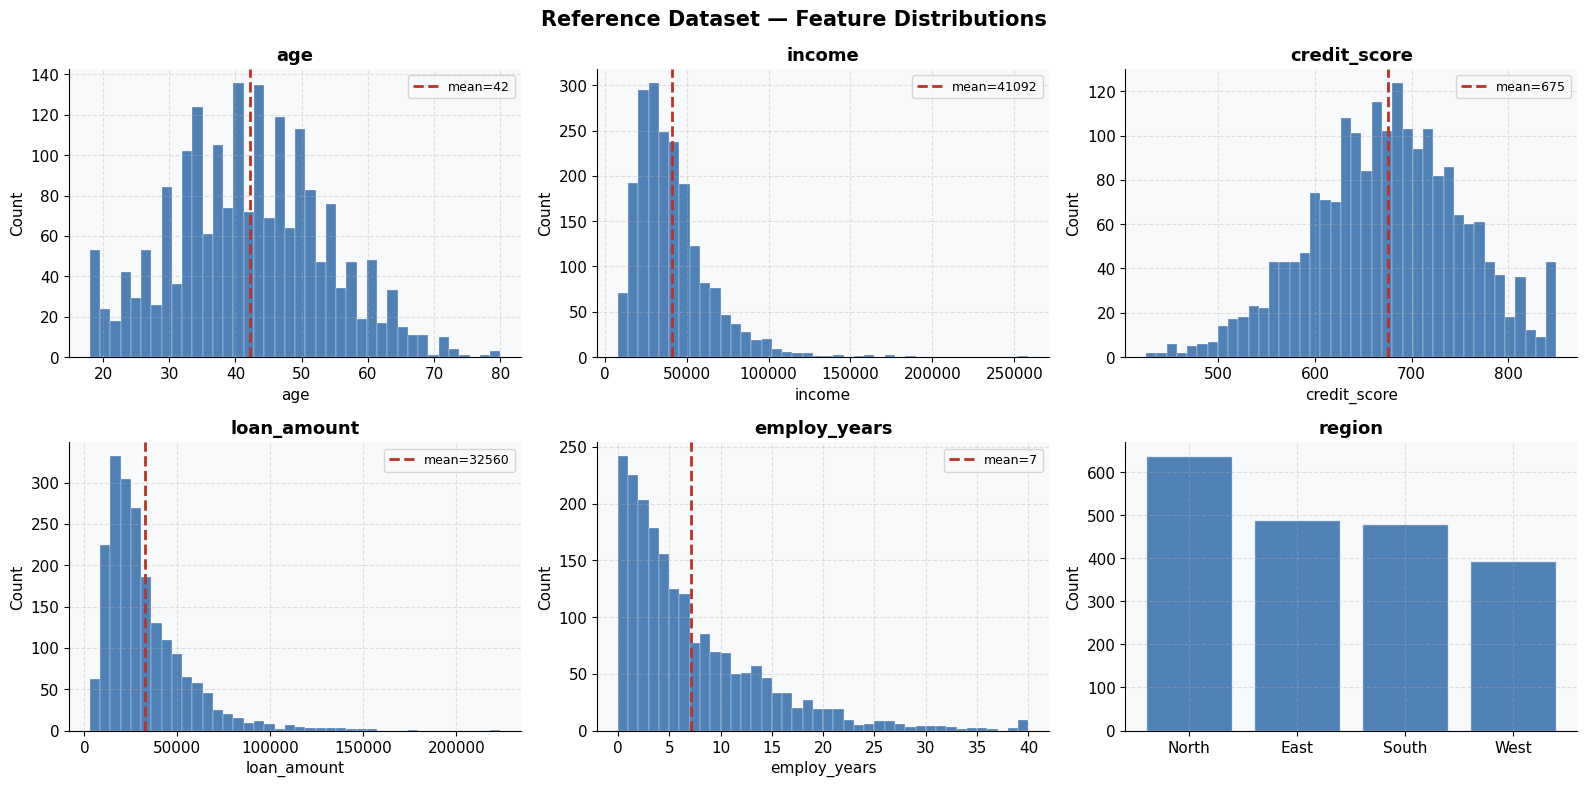

Reference dataset statistics:
          age    income  credit_score  loan_amount  employ_years
count  2000.0    2000.0        2000.0       2000.0        2000.0
mean     42.1   41091.7         675.2      32560.2           7.2
std      11.6   22249.1          78.7      22358.2           6.9
min      18.0    8024.0         425.0       2942.0           0.0
25%      34.0   25473.8         625.0      17409.2           2.1
50%      42.0   36314.0         677.0      26414.5           4.9
75%      50.0   50653.2         730.0      41200.8          10.2
max      80.0  258620.0         850.0     223559.0          40.0


In [3]:
NUM_COLS = ['age', 'income', 'credit_score', 'loan_amount', 'employ_years']
CAT_COLS = ['region']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Reference Dataset — Feature Distributions', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flat[:5], NUM_COLS):
    ax.hist(df_ref[col], bins=40, color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    mu, sd = df_ref[col].mean(), df_ref[col].std()
    ax.axvline(mu, color=RED, lw=2, linestyle='--', label=f'mean={mu:.0f}')
    ax.legend(fontsize=9)

# Categorical
ax = axes.flat[5]
counts = df_ref['region'].value_counts()
ax.bar(counts.index, counts.values, color=BLUE, alpha=0.75, edgecolor='white')
ax.set_title('region')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Reference dataset statistics:')
print(df_ref[NUM_COLS].describe().round(1))


## Section 2 — What Is Data Drift? (Formal Definition)

### The Core Problem

A supervised ML model learns a function $f: X \to Y$ that approximates $P(Y|X)$ under training distribution $P_{tr}(X,Y)$.

When deployed, the model sees samples from $P_{pr}(X,Y)$ — the **production** joint distribution.

$$\boxed{\text{Data Drift} \iff P_{tr}(X,Y) \neq P_{pr}(X,Y)}$$

### Why It Silently Kills Models

- No exception is thrown. The model still returns a prediction.
- Accuracy degrades gradually — unless you're measuring it.
- Ground truth labels arrive **late** (hours to months), so performance metrics lag.
- The model confidently gives wrong answers.

### The Joint Distribution Factorisation

$$P(X,Y) = \underbrace{P(X)}_{\text{feature dist.}} \cdot \underbrace{P(Y|X)}_{\text{concept}} = \underbrace{P(Y)}_{\text{label prior}} \cdot \underbrace{P(X|Y)}_{\text{class-cond.}}$$

Each factor can drift **independently**. This gives rise to the taxonomy in Section 3.

Training AUC (reference): 0.8424
  Reference (train)         AUC = 0.8424
  Covariate Shift           AUC = 0.8567
  Label Shift               AUC = 0.8306
  Concept Drift             AUC = 0.6153


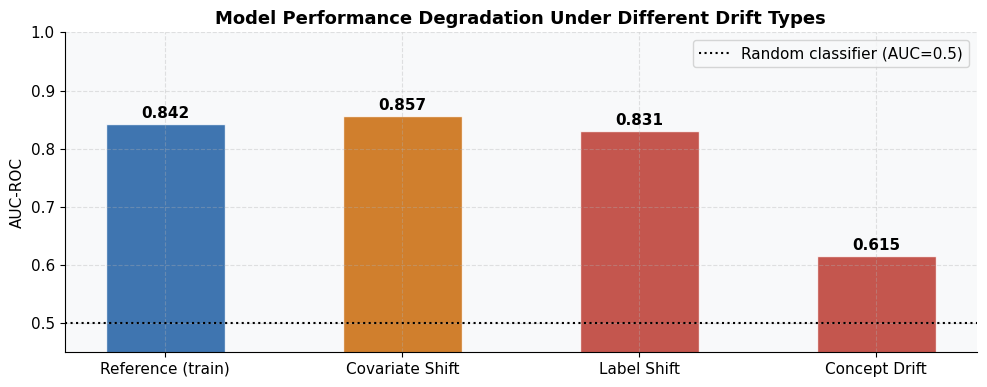

In [4]:
# ── Visualise: what model performance looks like when drift hits ─────
# Simulate: train on reference, score on production batches arriving weekly

# Train baseline model
feature_cols = ['age', 'income', 'credit_score', 'loan_amount', 'employ_years']

X_train = df_ref[feature_cols].values
y_train = df_ref['default'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

model = LogisticRegression(max_iter=500)
model.fit(X_train_s, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train_s)[:,1])
print(f'Training AUC (reference): {train_auc:.4f}')

# Score on each drift variant
results = []
for name, df in [('Reference (train)', df_ref),
                 ('Covariate Shift',   df_covariate),
                 ('Label Shift',       df_label),
                 ('Concept Drift',     df_concept)]:
    X = scaler.transform(df[feature_cols].values)
    y = df['default'].values
    auc = roc_auc_score(y, model.predict_proba(X)[:,1])
    results.append((name, auc))
    print(f'  {name:25s} AUC = {auc:.4f}')

# Plot the AUC degradation
names, aucs = zip(*results)
colors = [BLUE, ORANGE, RED, RED]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, aucs, color=colors, alpha=0.82, edgecolor='white', width=0.5)
ax.axhline(0.5, color='black', lw=1.5, linestyle=':', label='Random classifier (AUC=0.5)')
ax.set_ylim(0.45, 1.0)
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Performance Degradation Under Different Drift Types')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, auc + 0.01, f'{auc:.3f}',
            ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## Section 3 — Types of Data Drift

### 3.1 Covariate Shift

$$P_{tr}(X) \neq P_{pr}(X) \qquad P(Y|X) \text{ unchanged}$$

The **input feature distribution** changes but the relationship from inputs to labels stays the same.
The model is theoretically still correct, but it has to extrapolate into regions of low training density.

**Our scenario:** Post-pandemic, a wave of younger, gig-economy workers apply for loans. The income distribution shifts down and widens. The model was never trained on this population segment.

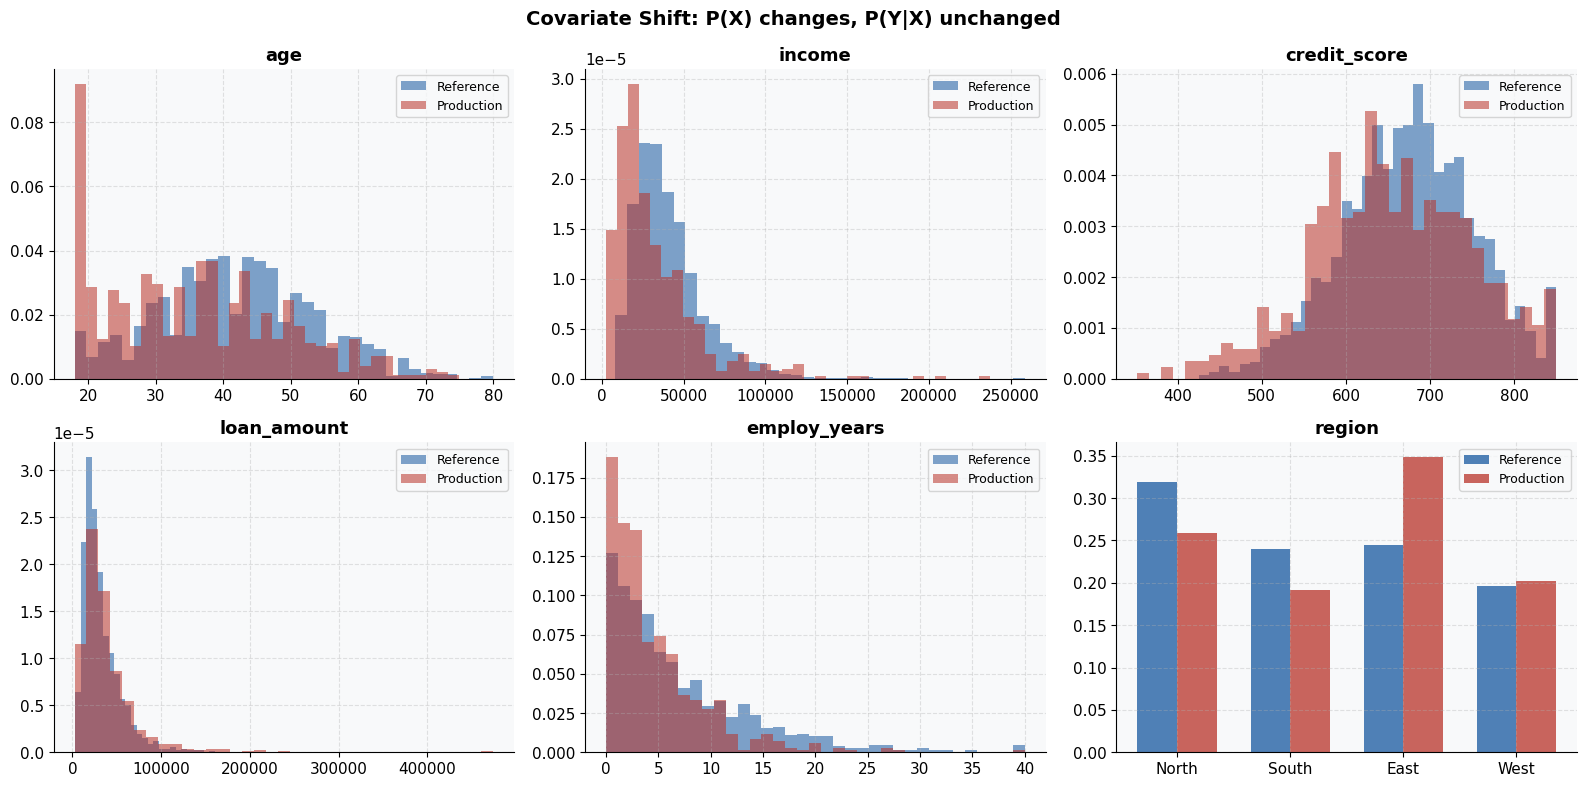

P(Y=1|X) relationship check — feature coefficients used in both:
  credit_score weight: -0.020 in BOTH reference and covariate
  income weight:       -0.800 in BOTH reference and covariate
  Reference default rate:  46.5%
  Covariate default rate:  61.8%
  -> Rate differs only because population changed, not the concept


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Covariate Shift: P(X) changes, P(Y|X) unchanged', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat[:5], NUM_COLS):
    ax.hist(df_ref[col], bins=35, color=BLUE, alpha=0.55, label='Reference', density=True)
    ax.hist(df_covariate[col], bins=35, color=RED, alpha=0.55, label='Production', density=True)
    ax.set_title(col)
    ax.legend(fontsize=9)

# Region
ax = axes.flat[5]
cats = ['North','South','East','West']
x = np.arange(len(cats))
w = 0.35
r_counts = df_ref['region'].value_counts().reindex(cats).fillna(0) / len(df_ref)
c_counts = df_covariate['region'].value_counts().reindex(cats).fillna(0) / len(df_covariate)
ax.bar(x - w/2, r_counts, w, color=BLUE, alpha=0.75, label='Reference')
ax.bar(x + w/2, c_counts, w, color=RED,  alpha=0.75, label='Production')
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_title('region')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Key insight: the label relationship is unchanged
print('P(Y=1|X) relationship check — feature coefficients used in both:')
print('  credit_score weight: -0.020 in BOTH reference and covariate')
print('  income weight:       -0.800 in BOTH reference and covariate')
print(f'  Reference default rate:  {df_ref["default"].mean():.1%}')
print(f'  Covariate default rate:  {df_covariate["default"].mean():.1%}')
print('  -> Rate differs only because population changed, not the concept')


### 3.2 Label / Prior Shift

$$P_{tr}(Y) \neq P_{pr}(Y) \qquad P(X|Y) \text{ unchanged}$$

The **class prior** changes — e.g., the overall default rate rises during a recession — but the distribution of features given class membership stays the same. This is the 'opposite' assumption to covariate shift.

**Our scenario:** Economic recession hits. Default rates climb across the board (intercept shift in logit), not because features predict differently, but because the underlying population risk increased uniformly.

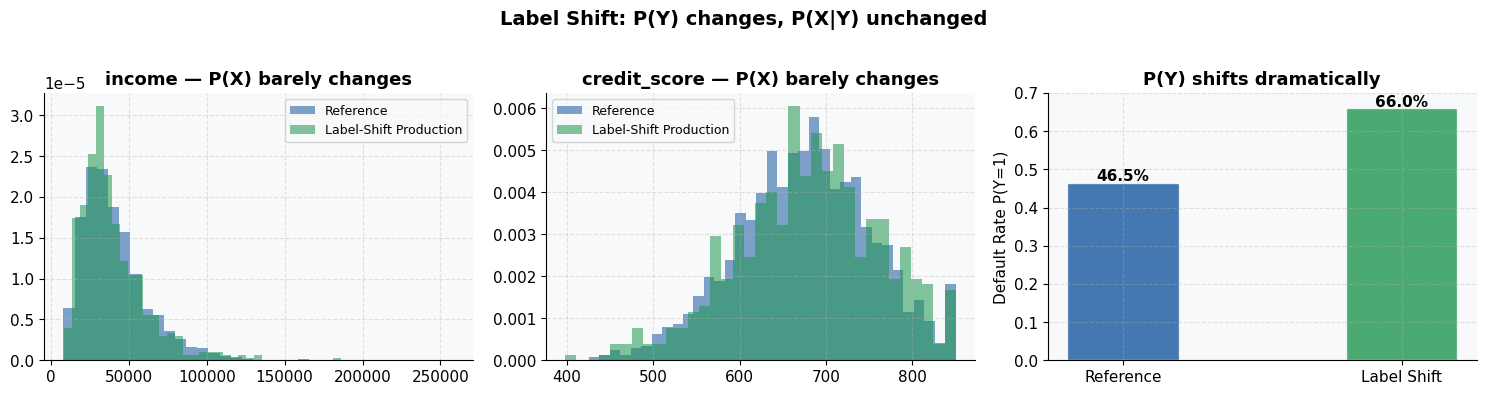

Label shift summary:
  Reference default rate:   46.5%
  Label-shift default rate: 66.0%
  income mean (ref):        41,092
  income mean (label):      39,855  <- almost the same


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Label Shift: P(Y) changes, P(X|Y) unchanged', fontsize=14, fontweight='bold')

# Show that P(X) is almost the same
for ax, col in zip(axes[:2], ['income', 'credit_score']):
    ax.hist(df_ref[col], bins=35, color=BLUE, alpha=0.55, label='Reference', density=True)
    ax.hist(df_label[col], bins=35, color=GREEN, alpha=0.55, label='Label-Shift Production', density=True)
    ax.set_title(f'{col} — P(X) barely changes')
    ax.legend(fontsize=9)

# Show that P(Y) changes dramatically
ax = axes[2]
labels = ['Reference', 'Label Shift']
rates  = [df_ref['default'].mean(), df_label['default'].mean()]
ax.bar(labels, rates, color=[BLUE, GREEN], alpha=0.8, edgecolor='white', width=0.4)
for i, r in enumerate(rates):
    ax.text(i, r + 0.005, f'{r:.1%}', ha='center', fontweight='bold')
ax.set_ylabel('Default Rate P(Y=1)')
ax.set_title('P(Y) shifts dramatically')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

print('Label shift summary:')
print(f'  Reference default rate:   {df_ref["default"].mean():.1%}')
print(f'  Label-shift default rate: {df_label["default"].mean():.1%}')
print(f'  income mean (ref):        {df_ref["income"].mean():,.0f}')
print(f'  income mean (label):      {df_label["income"].mean():,.0f}  <- almost the same')


### 3.3 Concept Drift

$$P_{tr}(Y|X) \neq P_{pr}(Y|X) \qquad P(X) \text{ unchanged}$$

The **relationship between inputs and output changes**. This is the most dangerous type:
the model learned the wrong function for current reality.

**Our scenario:** Fraudsters have learned to game credit scores. High credit scores no longer reliably predict low default risk. Instead, the loan-to-income ratio becomes the dominant predictor. The decision boundary the model learned is now wrong.

**Key insight:** $P(X)$ is identical to reference — feature monitoring alone would show NO drift. You need **model output monitoring** and **label feedback** to catch this.

**Subcategories of concept drift:**

| Type | Description | Example |
|------|-------------|----------|
| Sudden | Abrupt shift at time $t_0$ | New regulation changes underwriting rules |
| Gradual | Slow transition | User preferences shift over years |
| Incremental | Stepwise accumulation | Seasonal market changes |
| Recurring | Cyclical pattern | Holiday vs. non-holiday purchasing |


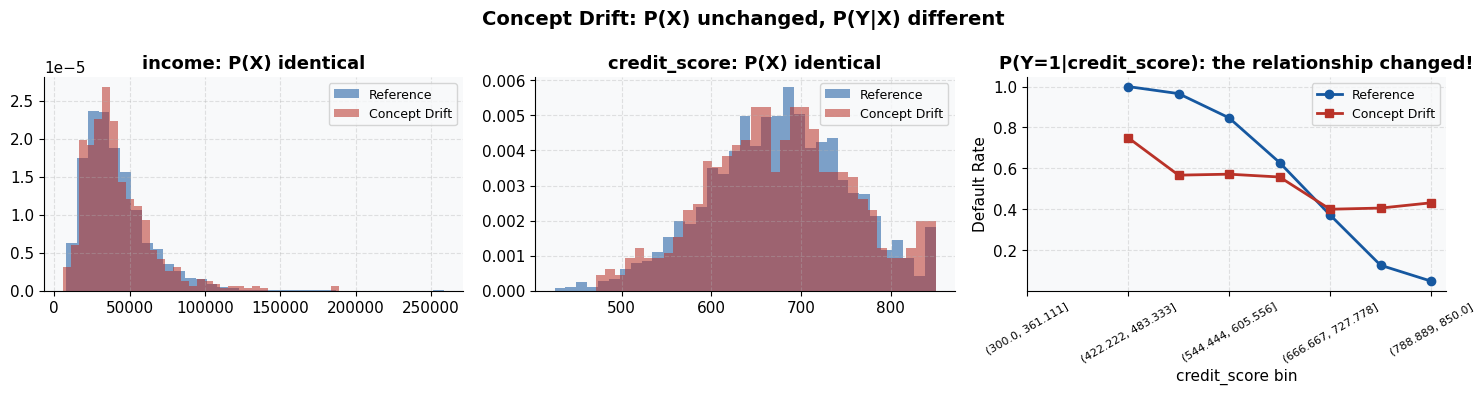

Concept drift insight:
  Reference:    credit_score weight = -0.020 (strong predictor)
  Concept drift: credit_score weight = -0.003 (near zero!)
  credit_score mean (ref): 675.2
  credit_score mean (con): 676.0  <- same distribution
  But AUC of original model drops: 0.6153


In [7]:
# Concept drift: P(X) same, P(Y|X) different
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Concept Drift: P(X) unchanged, P(Y|X) different', fontsize=14, fontweight='bold')

# P(X) is the same
for ax, col in zip(axes[:2], ['income', 'credit_score']):
    ax.hist(df_ref[col], bins=35, color=BLUE, alpha=0.55, label='Reference', density=True)
    ax.hist(df_concept[col], bins=35, color=RED, alpha=0.55, label='Concept Drift', density=True)
    ax.set_title(f'{col}: P(X) identical')
    ax.legend(fontsize=9)

# But credit_score vs default relationship has changed
ax = axes[2]
bins = np.linspace(300, 850, 10)
ref_grp = df_ref.copy()
ref_grp['cs_bin'] = pd.cut(df_ref['credit_score'], bins=bins)
con_grp = df_concept.copy()
con_grp['cs_bin'] = pd.cut(df_concept['credit_score'], bins=bins)

ref_def  = ref_grp.groupby('cs_bin')['default'].mean()
con_def  = con_grp.groupby('cs_bin')['default'].mean()

x_pos = range(len(ref_def))
ax.plot(x_pos, ref_def.values,  'o-', color=BLUE, lw=2, label='Reference')
ax.plot(x_pos, con_def.values,  's-', color=RED,  lw=2, label='Concept Drift')
ax.set_xticks(list(x_pos)[::2])
ax.set_xticklabels([str(b) for b in list(ref_def.index)[::2]], rotation=30, fontsize=8)
ax.set_xlabel('credit_score bin')
ax.set_ylabel('Default Rate')
ax.set_title('P(Y=1|credit_score): the relationship changed!')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Concept drift insight:')
print('  Reference:    credit_score weight = -0.020 (strong predictor)')
print('  Concept drift: credit_score weight = -0.003 (near zero!)')
print(f'  credit_score mean (ref): {df_ref["credit_score"].mean():.1f}')
print(f'  credit_score mean (con): {df_concept["credit_score"].mean():.1f}  <- same distribution')
print(f'  But AUC of original model drops: {roc_auc_score(df_concept["default"], model.predict_proba(scaler.transform(df_concept[feature_cols]))[:,1]):.4f}')


## Section 4 — Statistical Detection: Kolmogorov-Smirnov Test

### Theory

The KS test compares the **empirical cumulative distribution functions (CDFs)** of two samples. It is **non-parametric** — it makes no assumption about the underlying distribution.

$$D_{KS} = \sup_x \left| F_{ref}(x) - F_{cur}(x) \right|$$

where $F_{ref}$ and $F_{cur}$ are the empirical CDFs of the reference and current samples.

**Hypothesis test:**
- $H_0$: Both samples come from the same distribution
- $H_1$: The samples come from different distributions
- Reject $H_0$ if $p\text{-value} < \alpha$ (typically $\alpha = 0.05$)

**Sensitivity:** detects changes in location (mean shift), scale (variance shift), and shape (skewness).

**Limitation:** Univariate — apply per feature, not jointly.

In [ ]:
# ── Implement KS Test from scratch ───────────────────────────────────
def ks_drift_test(ref_series, cur_series, alpha=0.05):
    """
    Two-sample KS test for drift detection.
    Returns dict with statistic, p_value, drift flag, and interpretation.
    """
    stat, pval = ks_2samp(ref_series.dropna(), cur_series.dropna())
    return {
        'statistic': round(stat, 4),
        'p_value':   round(pval, 4),
        'drift':     pval < alpha,
        'severity':  'HIGH' if pval < 0.001 else ('MEDIUM' if pval < 0.05 else 'NONE')
    }

# ── Apply to all numeric features ────────────────────────────────────
print('KS Test: Reference vs Covariate Shift')
print('-' * 55)
print("  {0:<18} {1:>8} {2:>10} {3:>8}".format('Feature','D_KS','p-value','Drift?'))
print('-' * 55)
ks_results = {}
for col in NUM_COLS:
    res = ks_drift_test(df_ref[col], df_covariate[col])
    ks_results[col] = res
    flag = '*** DRIFT' if res['drift'] else 'ok'
    print(f"  {col:<18} {res['statistic']:>8.4f} {res['p_value']:>10.4f} {flag:>8}")
print()

print('KS Test: Reference vs Concept Drift (P(X) same!)')
print('-' * 55)
print(f"  {'Feature':<18} {'D_KS':>8} {'p-value':>10} {'Drift?':>8}")
print('-' * 55)
for col in NUM_COLS:
    res = ks_drift_test(df_ref[col], df_concept[col])
    flag = '*** DRIFT' if res['drift'] else 'ok'
    print(f"  {col:<18} {res['statistic']:>8.4f} {res['p_value']:>10.4f} {flag:>8}")
print()
print('Key insight: KS test misses concept drift because P(X) did not change!')


SyntaxError: f-string: expecting '}' (2475828547.py, line 18)

In [ ]:
# ── Visualise CDFs to understand what D_KS measures ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KS Test — CDF Comparison (Covariate Shift)', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['income', 'credit_score', 'employ_years']):
    ref_sorted = np.sort(df_ref[col])
    cur_sorted = np.sort(df_covariate[col])
    ref_cdf    = np.arange(1, len(ref_sorted)+1) / len(ref_sorted)
    cur_cdf    = np.arange(1, len(cur_sorted)+1) / len(cur_sorted)

    ax.plot(ref_sorted, ref_cdf, color=BLUE, lw=2, label='Reference CDF')
    ax.plot(cur_sorted, cur_cdf, color=RED,  lw=2, label='Production CDF', linestyle='--')

    # Find and annotate D_KS
    stat, _ = ks_2samp(df_ref[col], df_covariate[col])
    ax.set_title(f'{col}  |  D_KS = {stat:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('CDF')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── KS power: what size of shift is detectable? ───────────────────────
print('Minimum detectable mean shift vs sample size (credit_score, sigma=80):')
print(f"  {'N':>6} | {'Min detectable shift':>22} | Note")
print('-' * 55)
for n_cur in [50, 100, 250, 500, 1000]:
    # Empirical: at n=50 we need a larger shift to reliably detect at p<0.05
    # Approximate asymptotic: D_crit ~ 1.36 * sqrt((n+m)/(n*m)) at alpha=0.05
    n_ref = len(df_ref)
    d_crit = 1.36 * np.sqrt((n_ref + n_cur) / (n_ref * n_cur))
    # For normal dist: D_KS ~ 0.5 * |delta_mu| / sigma (rough rule)
    min_shift = d_crit * 80 / 0.5
    print(f"  {n_cur:>6} | {min_shift:>22.1f} pts | credit_score shift detectable")


## Section 5 — Population Stability Index (PSI)

### Theory

PSI was developed in the **credit risk** industry to monitor whether a scoring model's population has changed enough to invalidate it. It is now standard in ML monitoring.

**Algorithm:**
1. Bin the feature using **equal-frequency binning** (deciles) from the reference distribution
2. Count the proportion of samples falling in each bin for reference ($P_i^{ref}$) and current ($P_i^{cur}$)
3. Compute:

$$\text{PSI} = \sum_{i=1}^{k} \left(P_i^{cur} - P_i^{ref}\right) \cdot \ln\left(\frac{P_i^{cur}}{P_i^{ref}}\right)$$

**Interpretation thresholds** (industry standard):

| PSI | Status | Action |
|-----|--------|--------|
| < 0.10 | Stable | Monitor |
| 0.10 – 0.20 | Caution | Investigate |
| > 0.20 | Drift | Retrain / Alert |

**Note:** PSI is NOT a hypothesis test — it has no p-value. Use it alongside KS.

**Math note:** PSI = KL divergence of $P^{cur}$ vs $P^{ref}$ + KL divergence of $P^{ref}$ vs $P^{cur}$ = symmetric KL.

In [ ]:
# ── Implement PSI from scratch ────────────────────────────────────────
def compute_psi(ref_series, cur_series, n_bins=10, eps=1e-4):
    """
    Population Stability Index.
    Uses equal-frequency bins from reference distribution.
    eps avoids log(0) for empty bins.
    """
    ref_clean = ref_series.dropna()
    cur_clean = cur_series.dropna()

    # Build quantile-based bins from reference
    _, bin_edges = pd.qcut(ref_clean, q=n_bins, retbins=True, duplicates='drop')
    bin_edges[0]  = -np.inf
    bin_edges[-1] = np.inf

    ref_counts = pd.cut(ref_clean, bins=bin_edges).value_counts(sort=False).values.astype(float)
    cur_counts = pd.cut(cur_clean, bins=bin_edges).value_counts(sort=False).values.astype(float)

    # Proportions
    ref_pct = ref_counts / ref_counts.sum()
    cur_pct = cur_counts / cur_counts.sum()

    # Avoid log(0) with epsilon
    ref_pct = np.where(ref_pct == 0, eps, ref_pct)
    cur_pct = np.where(cur_pct == 0, eps, cur_pct)

    psi_per_bin = (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
    psi_total   = psi_per_bin.sum()

    return {
        'psi':         round(float(psi_total), 4),
        'psi_per_bin': psi_per_bin,
        'ref_pct':     ref_pct,
        'cur_pct':     cur_pct,
        'bin_edges':   bin_edges,
        'drift':       psi_total > 0.20,
        'severity':    'HIGH'   if psi_total > 0.20
                       else ('MEDIUM' if psi_total > 0.10 else 'NONE')
    }

# ── Compare PSI across all three drift types ──────────────────────────
print('PSI Results Across Drift Types')
print('=' * 65)
for drift_name, df_cur in [('Covariate', df_covariate), ('Label', df_label), ('Concept', df_concept)]:
    print(f"\n  {drift_name} Shift:")
    print(f"  {'Feature':<18} {'PSI':>8} {'Status':>10}")
    print('  ' + '-' * 38)
    for col in NUM_COLS:
        res = compute_psi(df_ref[col], df_cur[col])
        status = f"[{res['severity']}]"
        print(f"  {col:<18} {res['psi']:>8.4f} {status:>10}")


In [ ]:
# ── Visualise PSI bucket breakdown for 'income' (most drifted feature) ──
res = compute_psi(df_ref['income'], df_covariate['income'], n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"PSI Analysis: 'income' feature  |  PSI = {res['psi']:.4f}  ({res['severity']})",
             fontsize=13, fontweight='bold')

# Left: bucket proportions
ax = axes[0]
x  = np.arange(len(res['ref_pct']))
w  = 0.35
ax.bar(x - w/2, res['ref_pct'], w, color=BLUE, alpha=0.8, label='Reference')
ax.bar(x + w/2, res['cur_pct'], w, color=RED,  alpha=0.8, label='Production')
ax.set_xlabel('Bin index (decile from reference)')
ax.set_ylabel('Proportion')
ax.set_title('Proportion per Bin')
ax.legend()

# Right: PSI contribution per bin
ax = axes[1]
colors_bin = [RED if v > 0.02 else ORANGE if v > 0.005 else GREEN
              for v in res['psi_per_bin']]
ax.bar(x, res['psi_per_bin'], color=colors_bin, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Bin index')
ax.set_ylabel('PSI contribution')
ax.set_title('PSI Contribution per Bin')
ax.text(0.98, 0.95, f'Total PSI = {res["psi"]:.4f}', transform=ax.transAxes,
        ha='right', va='top', fontweight='bold', color=RED)

plt.tight_layout()
plt.show()


## Section 6 — Chi-Squared Test (Categorical Features)

### Theory

For **categorical features**, the KS test and PSI do not apply directly. The chi-squared goodness-of-fit test compares observed category frequencies against expected ones.

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}, \quad \text{df} = k-1$$

where:
- $O_i$ = observed count of category $i$ in current data
- $E_i$ = expected count = reference proportion $\times$ $n_{cur}$
- $k$ = number of categories

**Requirements:**
- $E_i \geq 5$ for each cell (merge rare categories if violated)
- New categories that appear only in production = always drift

**Note:** Use a **contingency table** approach via `chi2_contingency` to compare two samples.

In [ ]:
# ── Implement Chi-Squared test for categorical drift ──────────────────
def chi2_drift_test(ref_series, cur_series, alpha=0.05):
    """
    Chi-squared two-sample test for categorical feature drift.
    Builds a 2xK contingency table (ref vs cur).
    """
    all_cats   = sorted(set(ref_series.unique()) | set(cur_series.unique()))
    ref_counts = ref_series.value_counts().reindex(all_cats, fill_value=0)
    cur_counts = cur_series.value_counts().reindex(all_cats, fill_value=0)

    # Check for new categories only in production
    new_cats = [c for c in cur_series.unique() if c not in ref_series.unique()]
    if new_cats:
        print(f'  WARNING: new categories in production: {new_cats}')

    # Build 2 x K contingency table
    contingency = np.array([ref_counts.values, cur_counts.values])

    # Drop columns where both are zero
    contingency = contingency[:, contingency.sum(axis=0) > 0]

    chi2_stat, pval, dof, expected = chi2_contingency(contingency)

    # Check minimum expected frequency
    min_expected = expected.min()
    if min_expected < 5:
        print(f'  WARNING: min expected count = {min_expected:.1f} < 5, consider merging categories')

    return {
        'statistic':    round(chi2_stat, 4),
        'p_value':      round(pval, 4),
        'dof':          dof,
        'drift':        pval < alpha,
        'new_cats':     new_cats,
        'ref_counts':   ref_counts,
        'cur_counts':   cur_counts,
        'severity':     'HIGH' if pval < 0.001 else ('MEDIUM' if pval < 0.05 else 'NONE')
    }

# Apply to region feature across all drift types
print('Chi-Squared Test on categorical feature: region')
print('=' * 60)
for name, df_cur in [('Covariate', df_covariate), ('Label', df_label), ('Concept', df_concept)]:
    res = chi2_drift_test(df_ref['region'], df_cur['region'])
    print(f"  {name}: chi2={res['statistic']:.3f}  p={res['p_value']:.4f}  "
          f"dof={res['dof']}  {'DRIFT' if res['drift'] else 'ok'}")

# Visualise the category shift
res = chi2_drift_test(df_ref['region'], df_covariate['region'])
cats = res['ref_counts'].index
x    = np.arange(len(cats))
w    = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, res['ref_counts'].values / res['ref_counts'].sum(), w,
       color=BLUE, alpha=0.8, label='Reference')
ax.bar(x + w/2, res['cur_counts'].values / res['cur_counts'].sum(), w,
       color=RED, alpha=0.8, label='Production (Covariate)')
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel('Proportion')
ax.set_title(f"region drift  |  chi2={res['statistic']:.2f}  p={res['p_value']:.4f}  [{res['severity']}]")
ax.legend()
plt.tight_layout()
plt.show()


## Section 7 — Maximum Mean Discrepancy (MMD)

### Why We Need MMD

KS, PSI, and Chi-squared are all **univariate** — they test each feature independently. They completely miss **joint distribution shifts** where individual marginals look fine but the correlation structure changes.

**Example:** `income` and `credit_score` each look the same, but their correlation inverts (high income + low score was rare, now it's common). Univariate tests: no alarm. MMD: alarm.

### Theory

MMD measures the **distance between two distributions** in a Reproducing Kernel Hilbert Space (RKHS).

$$\text{MMD}^2(P,Q) = \mathbb{E}_{x,x'\sim P}[k(x,x')] - 2\,\mathbb{E}_{\substack{x\sim P \\ y\sim Q}}[k(x,y)] + \mathbb{E}_{y,y'\sim Q}[k(y,y')]$$

With the **RBF kernel**: $k(x,y) = \exp\!\left(-\|x-y\|^2 / 2\sigma^2\right)$

**Key property:** $\text{MMD}^2 = 0 \iff P = Q$ (in the RKHS)

**Significance:** Use a **permutation test** — shuffle the combined dataset labels and recompute MMD$^2$ many times to build the null distribution.

**Complexity:** $O(n^2)$ — expensive at scale. Use Random Fourier Features for approximation.

In [ ]:
# ── Implement MMD from scratch ─────────────────────────────────────────
def rbf_kernel(X, Y, sigma=1.0):
    """Compute RBF kernel matrix K[i,j] = exp(-||X[i]-Y[j]||^2 / (2*sigma^2))"""
    XY = X @ Y.T
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    dist_sq = XX - 2*XY + YY.T
    return np.exp(-dist_sq / (2 * sigma**2))

def compute_mmd_squared(X, Y, sigma='median'):
    """
    Unbiased estimate of MMD^2 with RBF kernel.
    sigma='median' uses the median heuristic: sigma = median(||x-y||)
    """
    if sigma == 'median':
        # Median heuristic: good default bandwidth
        combined = np.vstack([X, Y])
        # Sample for speed
        sample_idx = np.random.choice(len(combined), min(500, len(combined)), replace=False)
        sample = combined[sample_idx]
        diffs  = sample[:, None, :] - sample[None, :, :]
        dists  = np.sqrt((diffs**2).sum(axis=-1))
        sigma  = np.median(dists[dists > 0])

    n, m = len(X), len(Y)
    Kxx   = rbf_kernel(X, X, sigma)
    Kyy   = rbf_kernel(Y, Y, sigma)
    Kxy   = rbf_kernel(X, Y, sigma)

    # Unbiased estimate (zero diagonal for Kxx, Kyy)
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)
    mmd2 = (Kxx.sum() / (n*(n-1))
          + Kyy.sum() / (m*(m-1))
          - 2 * Kxy.mean())
    return float(mmd2), float(sigma)

def mmd_permutation_test(X, Y, n_permutations=200, alpha=0.05):
    """
    Permutation test for MMD significance.
    Builds null distribution by shuffling labels.
    """
    observed_mmd2, sigma = compute_mmd_squared(X, Y)
    combined = np.vstack([X, Y])
    n = len(X)
    null_mmd2s = []
    for _ in range(n_permutations):
        perm     = np.random.permutation(len(combined))
        X_perm   = combined[perm[:n]]
        Y_perm   = combined[perm[n:]]
        null_val, _ = compute_mmd_squared(X_perm, Y_perm, sigma=sigma)
        null_mmd2s.append(null_val)
    p_value = (np.sum(np.array(null_mmd2s) >= observed_mmd2) + 1) / (n_permutations + 1)
    return {
        'mmd2':       round(observed_mmd2, 6),
        'p_value':    round(p_value, 4),
        'drift':      p_value < alpha,
        'null_dist':  null_mmd2s,
        'sigma':      round(sigma, 4)
    }

# ── Prepare scaled feature matrices ──────────────────────────────────
sc = StandardScaler().fit(df_ref[NUM_COLS].values)
X_ref_s = sc.transform(df_ref[NUM_COLS].values[:300])    # subsample for speed
X_cov_s = sc.transform(df_covariate[NUM_COLS].values)
X_con_s = sc.transform(df_concept[NUM_COLS].values)

print('Running MMD permutation tests (200 permutations each)...')
res_cov = mmd_permutation_test(X_ref_s, X_cov_s, n_permutations=200)
res_con = mmd_permutation_test(X_ref_s, X_con_s, n_permutations=200)

print(f"  Covariate drift:  MMD^2={res_cov['mmd2']:.6f}  p={res_cov['p_value']:.4f}  "
      f"{'DRIFT' if res_cov['drift'] else 'ok'} (sigma={res_cov['sigma']:.2f})")
print(f"  Concept drift:    MMD^2={res_con['mmd2']:.6f}  p={res_con['p_value']:.4f}  "
      f"{'DRIFT' if res_con['drift'] else 'ok'} (sigma={res_con['sigma']:.2f})")
print()
print('Note: Concept drift MMD is low because P(X) is identical.')
print('MMD on predictions or residuals would catch concept drift.')


In [ ]:
# ── Visualise the MMD null distribution vs observed statistic ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('MMD Permutation Test — Null Distribution vs Observed', fontsize=13, fontweight='bold')

for ax, res, title in zip(axes,
                           [res_cov, res_con],
                           ['Covariate Shift', 'Concept Drift']):
    ax.hist(res['null_dist'], bins=30, color=GRAY, alpha=0.7,
            edgecolor='white', label='Null distribution (permutations)')
    ax.axvline(res['mmd2'], color=RED if res['drift'] else GREEN, lw=2.5,
               label=f"Observed MMD^2 = {res['mmd2']:.5f}", linestyle='--')
    ax.set_xlabel('MMD^2')
    ax.set_ylabel('Count')
    ax.set_title(f"{title}  |  p = {res['p_value']:.4f}  |  {'DRIFT' if res['drift'] else 'NO DRIFT'}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Show MMD catching joint distribution change that marginals miss ───
print('Demonstrating MMD catching joint drift while KS misses it:')
rng = np.random.RandomState(0)
n = 400
# Reference: income and credit_score positively correlated
cov_ref = [[1, 0.7], [0.7, 1]]
X_joint_ref = rng.multivariate_normal([0, 0], cov_ref, n)
# Production: same marginals, correlation reversed
cov_cur = [[1, -0.7], [-0.7, 1]]
X_joint_cur = rng.multivariate_normal([0, 0], cov_cur, n)

# KS test on each marginal
ks_x, _ = ks_2samp(X_joint_ref[:,0], X_joint_cur[:,0])
ks_y, _ = ks_2samp(X_joint_ref[:,1], X_joint_cur[:,1])
mmd_joint = mmd_permutation_test(X_joint_ref, X_joint_cur, n_permutations=200)

print(f'  KS on feature 1 (marginal): D={ks_x:.4f}  -> same distribution')
print(f'  KS on feature 2 (marginal): D={ks_y:.4f}  -> same distribution')
print(f'  MMD^2 (joint):              {mmd_joint["mmd2"]:.6f}  p={mmd_joint["p_value"]:.4f}  -> DRIFT DETECTED')
print('  -> MMD detects the correlation flip that KS completely misses!')


## Section 8 — ADWIN: Adaptive Windowing for Streaming Drift

All methods above are **batch** methods — they compare two pre-defined windows. For real-time streaming (Kafka, Flink), we need an **online** method.

### ADWIN Algorithm

ADWIN maintains a window $W$ of recent observations. At each step it asks:
'Is there a cut-point $t$ in $W$ where the two halves have significantly different means?'

$$\left|\hat{\mu}_{W_0} - \hat{\mu}_{W_1}\right| \geq \varepsilon_{\text{cut}}$$

where $\varepsilon_{\text{cut}} = \sqrt{\frac{1}{2m} \cdot \ln\frac{4|W|\log|W|}{\delta}}$, $m = \frac{n_0 n_1}{n_0+n_1}$ (harmonic mean of sub-window sizes), $\delta$ = confidence parameter.

**If drift found:** drop the older sub-window $W_0$, shrink the window.

**Properties:**
- Window size adapts automatically — no fixed parameter to tune
- $O(|W|)$ per sample — efficient
- Works on any 1D statistic: accuracy, feature mean, error rate
- Available in `River` library: `from river import drift; drift.ADWIN()`

In [ ]:
# ── ADWIN Implementation from Scratch ────────────────────────────────
class ADWIN:
    """
    Adaptive Windowing (ADWIN) drift detector.
    Reference: Bifet & Gavalda, 2007.

    Parameters
    ----------
    delta : float
        Confidence parameter. Smaller = more sensitive but more false positives.
        Typical range: 0.001 - 0.01
    """
    def __init__(self, delta=0.002):
        self.delta         = delta
        self.window        = []
        self.drift_detected = False
        self.n_detections  = 0
        self.detection_idx = []

    def update(self, value, idx=None):
        """Add a new observation and check for drift."""
        self.window.append(value)
        self.drift_detected = False
        self._check_drift(idx)
        return self.drift_detected

    def _check_drift(self, idx=None):
        n = len(self.window)
        if n < 4:
            return
        total_sum = sum(self.window)
        prefix_sum = 0
        for i in range(1, n):
            prefix_sum += self.window[i-1]
            n0 = i
            n1 = n - i
            mu0 = prefix_sum / n0
            mu1 = (total_sum - prefix_sum) / n1
            # Harmonic mean of sub-window sizes
            m = (n0 * n1) / (n0 + n1)
            # Hoeffding-style cut-off
            eps_cut = np.sqrt((1.0 / (2.0 * m)) * np.log(4.0 * np.log2(max(n, 2)) / self.delta))
            if abs(mu0 - mu1) >= eps_cut:
                self.drift_detected = True
                self.n_detections  += 1
                if idx is not None:
                    self.detection_idx.append(idx)
                self.window = self.window[i:]  # drop older portion
                return

    @property
    def window_size(self):
        return len(self.window)

print('ADWIN class defined.')
print(f'Parameters: delta (default=0.002), smaller = more sensitive')


In [ ]:
# ── Simulate a stream with sudden drift at t=500 ──────────────────────
rng_stream = np.random.RandomState(55)

# Generate stream: normal(0.3, 0.1) then shifts to normal(0.6, 0.1)
n_pre  = 500
n_post = 500
stream_pre  = rng_stream.normal(0.30, 0.10, n_pre)
stream_post = rng_stream.normal(0.65, 0.10, n_post)
stream      = np.concatenate([stream_pre, stream_post])
drift_point = n_pre  # true drift location

detector = ADWIN(delta=0.002)
values   = []
detected_at = []

for i, x in enumerate(stream):
    drift = detector.update(x, idx=i)
    values.append(x)
    if drift:
        detected_at.append(i)

print(f'Drift injected at:  t = {drift_point}')
print(f'ADWIN detected at:  t = {detected_at}')
print(f'Detection delay:    {detected_at[0] - drift_point if detected_at else "N/A"} samples')
print(f'Final window size:  {detector.window_size} samples')

# ── Visualise the stream and detection ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('ADWIN — Real-time Drift Detection in Streaming Data', fontsize=13, fontweight='bold')

# Raw stream
ax1.plot(stream, alpha=0.4, color=GRAY, lw=0.7, label='Stream values')
# Rolling mean
roll_mean = pd.Series(stream).rolling(30).mean()
ax1.plot(roll_mean, color=BLUE, lw=2, label='Rolling mean (w=30)')
ax1.axvline(drift_point, color=ORANGE, lw=2, linestyle='--', label=f'True drift point (t={drift_point})')
for d in detected_at:
    ax1.axvline(d, color=RED, lw=2.5, linestyle='-', label=f'ADWIN detects (t={d})')
ax1.set_ylabel('Stream value')
ax1.legend(fontsize=9)

# Cumulative mean to show the shift clearly
cumulative_means = [np.mean(stream[:i+1]) for i in range(len(stream))]
ax2.plot(cumulative_means, color=BLUE, lw=1.5, label='Cumulative mean')
ax2.axhline(0.30, color=BLUE, lw=1, linestyle=':', alpha=0.5, label='Pre-drift mean=0.30')
ax2.axhline(0.65, color=RED,  lw=1, linestyle=':', alpha=0.5, label='Post-drift mean=0.65')
ax2.axvline(drift_point, color=ORANGE, lw=2, linestyle='--')
for d in detected_at:
    ax2.axvline(d, color=RED, lw=2.5)
ax2.set_xlabel('Sample index (time)')
ax2.set_ylabel('Cumulative mean')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Section 9 — Multiple Testing Correction

### The Problem

When we test $d$ features simultaneously at significance level $\alpha = 0.05$, the probability of at least one **false positive** is:

$$P(\text{at least one false alarm}) = 1 - (1-\alpha)^d$$

With $d=20$ features: $1 - 0.95^{20} \approx 64\%$ chance of a false alarm even with NO real drift!

### Solutions

**1. Bonferroni Correction (conservative):** Control Family-Wise Error Rate (FWER)
$$\alpha_{\text{Bonferroni}} = \alpha / d$$

**2. Benjamini-Hochberg (BH) (less conservative):** Control False Discovery Rate (FDR = expected proportion of false discoveries)
- Sort p-values: $p_{(1)} \leq p_{(2)} \leq \ldots \leq p_{(d)}$
- Find largest $k$ such that $p_{(k)} \leq (k/d) \cdot \alpha$
- Reject all $H_0^{(i)}$ for $i \leq k$

**When to use which:**
- **Bonferroni:** when any false alarm is costly (medical, finance)
- **BH:** when you can tolerate a small proportion of false discoveries; more power in high-d settings

In [ ]:
# ── Demonstrate the multiple testing inflation ────────────────────────
d_values = [1, 5, 10, 20, 50, 100]
alpha = 0.05
false_alarm_rates = [1 - (1-alpha)**d for d in d_values]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d_values, false_alarm_rates, 'o-', color=RED, lw=2.5, markersize=8)
ax.axhline(alpha, color=BLUE, lw=1.5, linestyle='--', label=f'Desired alpha={alpha}')
ax.axhline(0.64, color=ORANGE, lw=1, linestyle=':', alpha=0.7)
ax.annotate('64% at d=20!', xy=(20, 0.64), fontsize=10, color=ORANGE,
            xytext=(25, 0.62), arrowprops=dict(arrowstyle='->', color=ORANGE))
ax.set_xlabel('Number of features tested (d)')
ax.set_ylabel('P(at least one false alarm)')
ax.set_title('Multiple Testing Problem: False Alarm Rate Inflation')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Implement Bonferroni and BH corrections ───────────────────────────
def bonferroni_correction(p_values, alpha=0.05):
    """Bonferroni: reject if p < alpha/d"""
    d = len(p_values)
    alpha_corrected = alpha / d
    rejected = {f: p < alpha_corrected for f, p in p_values.items()}
    return rejected, alpha_corrected

def benjamini_hochberg(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR correction."""
    items  = sorted(p_values.items(), key=lambda x: x[1])
    names  = [x[0] for x in items]
    pvals  = np.array([x[1] for x in items])
    d      = len(pvals)
    # BH thresholds
    thresholds = np.arange(1, d+1) / d * alpha
    # Find largest k such that p_(k) <= (k/d)*alpha
    below = pvals <= thresholds
    k     = np.max(np.where(below)[0]) + 1 if below.any() else 0
    rejected = {n: (i < k) for i, n in enumerate(names)}
    return rejected

# ── Run all KS tests and compare corrections ──────────────────────────
raw_pvals = {}
for col in NUM_COLS:
    _, pval = ks_2samp(df_ref[col], df_covariate[col])
    raw_pvals[col] = round(pval, 5)

bon_rejected, alpha_bon = bonferroni_correction(raw_pvals, alpha=0.05)
bh_rejected              = benjamini_hochberg(raw_pvals, alpha=0.05)

print(f'Multiple Testing Results (d={len(raw_pvals)} features, alpha=0.05)')
print(f'{"Feature":<18} {"Raw p":>10} {"Naive":>8} {"Bonferroni":>12} {"BH (FDR)":>10}')
print('-' * 65)
for col in NUM_COLS:
    p     = raw_pvals[col]
    naive = 'YES' if p < 0.05 else 'no'
    bon   = 'YES' if bon_rejected[col] else 'no'
    bh    = 'YES' if bh_rejected[col] else 'no'
    print(f'{col:<18} {p:>10.5f} {naive:>8} {bon:>12} {bh:>10}')
print(f'\nBonferroni alpha: {alpha_bon:.5f} = 0.05/{len(raw_pvals)}')
print('BH controls FDR (proportion of false discoveries) rather than FWER')


## Section 10 — Rolling Production Monitoring

In production you don't compare two static snapshots — you monitor **continuously** as new batches of data arrive.

### Strategy: Reference vs Rolling Windows

- Keep a **fixed reference window** (your versioned training dataset)
- Each week (or day), collect a **current window** of production data
- Run drift tests on each window and track the drift scores over time

### What to monitor:

| Signal | Type | Requires Labels? | Latency |
|--------|------|-----------------|----------|
| Feature distributions P(X) | Leading | No | Immediate |
| Prediction score distribution P(Yhat) | Leading | No | Immediate |
| Model accuracy / AUC | Lagging | Yes | Days-Months |
| Calibration error | Lagging | Yes | Days-Months |

**Monitor feature distributions immediately. Confirm concept drift when labels arrive.**

In [ ]:
# ── Simulate 12 weeks of production with gradual drift ────────────────
# Drift starts mild at week 4, becomes severe by week 12

def generate_gradual_drift(n, week, total_weeks=12, seed=None):
    """
    Generate data where drift increases linearly from week 4 onward.
    drift_intensity: 0 at week 4, 1.0 at week 12.
    """
    rng = np.random.RandomState(seed)
    drift_intensity = max(0, (week - 4) / (total_weeks - 4))

    # Reference distributions interpolated toward covariate-shift distribution
    age_mean   = 42  - drift_intensity * 7
    inc_lmean  = 10.5 - drift_intensity * 0.4
    cs_mean    = 680  - drift_intensity * 30
    emp_mean   = 7    - drift_intensity * 3
    region_p   = [0.30 - drift_intensity*0.08,
                  0.25 - drift_intensity*0.07,
                  0.25 + drift_intensity*0.15,
                  0.20]
    region_p = np.array(region_p)
    region_p = np.clip(region_p, 0.01, 1)
    region_p /= region_p.sum()

    age          = rng.normal(age_mean, 12+drift_intensity*2, n).clip(18,80).astype(int)
    income       = rng.lognormal(inc_lmean, 0.5+drift_intensity*0.25, n)
    credit_score = rng.normal(cs_mean, 80+drift_intensity*15, n).clip(300,850).astype(int)
    loan_amount  = rng.lognormal(10.2, 0.6, n)
    employ_years = rng.exponential(emp_mean, n).clip(0,40)
    region       = rng.choice(['North','South','East','West'], n, p=region_p)

    logit = (- 0.020 * (credit_score - 680)
             - 0.800 * np.log(income / np.exp(10.5))
             + 0.030 * (loan_amount / income)
             - 0.050 * employ_years
             + 0.010 * np.maximum(0, 45 - age))
    p_default = 1 / (1 + np.exp(-logit))
    default   = rng.binomial(1, p_default)

    return pd.DataFrame({'age':age, 'income':income.astype(int),
                         'credit_score':credit_score, 'loan_amount':loan_amount.astype(int),
                         'employ_years':employ_years.round(1),
                         'region':region, 'default':default})

# Generate 12 weekly production batches
WEEKS = 12
weekly_data = {w: generate_gradual_drift(n=200, week=w, seed=w*10) for w in range(1, WEEKS+1)}

print('Weekly data generated:')
for w, df_w in list(weekly_data.items())[::3]:
    dr = df_w['default'].mean()
    print(f'  Week {w:2d}: {len(df_w)} samples, default_rate={dr:.1%}')


In [ ]:
# ── Compute rolling drift scores ──────────────────────────────────────
weekly_scores = []

for week, df_w in weekly_data.items():
    week_scores = {'week': week}
    # KS test for each numeric feature
    for col in NUM_COLS:
        stat, pval = ks_2samp(df_ref[col], df_w[col])
        week_scores[f'ks_{col}']   = stat
        week_scores[f'psi_{col}']  = compute_psi(df_ref[col], df_w[col])['psi']
    # Model prediction score drift
    X_w = scaler.transform(df_w[feature_cols].values)
    scores = model.predict_proba(X_w)[:,1]
    ref_scores = model.predict_proba(X_train_s)[:,1]
    stat_score, _ = ks_2samp(ref_scores, scores)
    week_scores['ks_pred_score'] = stat_score
    week_scores['default_rate']  = df_w['default'].mean()
    weekly_scores.append(week_scores)

drift_df = pd.DataFrame(weekly_scores).set_index('week')

# ── Dashboard Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Production Drift Dashboard — 12 Weeks of Monitoring', fontsize=14, fontweight='bold')

weeks = drift_df.index

# Panel 1: KS statistics per feature
ax = axes[0]
colors_feats = [BLUE, RED, GREEN, ORANGE, GRAY]
for col, c in zip(NUM_COLS, colors_feats):
    ax.plot(weeks, drift_df[f'ks_{col}'], 'o-', color=c, lw=2, label=col, alpha=0.85)
ax.axhline(0.20, color='black', lw=1.5, linestyle='--', label='Alert threshold (D=0.20)')
ax.fill_between(weeks, 0.20, drift_df[[f'ks_{c}' for c in NUM_COLS]].max(axis=1).clip(0, 1.0),
                alpha=0.08, color=RED)
ax.set_ylabel('KS Statistic')
ax.set_title('Feature Drift Scores (KS Statistic per Week)')
ax.legend(fontsize=9, ncol=3)

# Panel 2: PSI for top features
ax = axes[1]
for col, c in zip(['income', 'credit_score', 'employ_years'], [BLUE, RED, GREEN]):
    ax.plot(weeks, drift_df[f'psi_{col}'], 'o-', color=c, lw=2, label=col, alpha=0.85)
ax.axhline(0.10, color=ORANGE, lw=1.5, linestyle='--', label='Caution (PSI=0.10)')
ax.axhline(0.20, color=RED,    lw=1.5, linestyle='--', label='Alert (PSI=0.20)')
ax.set_ylabel('PSI')
ax.set_title('Population Stability Index per Feature')
ax.legend(fontsize=9, ncol=3)

# Panel 3: Prediction score drift + default rate
ax3 = axes[2]
ax3.plot(weeks, drift_df['ks_pred_score'], 'o-', color=BLUE, lw=2.5, label='Prediction Score KS')
ax3.set_ylabel('KS Statistic (pred scores)', color=BLUE)
ax3b = ax3.twinx()
ax3b.plot(weeks, drift_df['default_rate'], 's--', color=RED, lw=2, label='Default Rate (lagging)')
ax3b.set_ylabel('Default Rate', color=RED)
ax3.set_xlabel('Week')
ax3.set_title('Prediction Score Drift (leading) vs Default Rate (lagging)')
ax3.axhline(0.20, color='black', lw=1, linestyle=':', alpha=0.5)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.tight_layout()
plt.show()

print('Key observation: prediction score KS drift is detectable at week 5-6')
print('without waiting for labels. Default rate confirms at week 7-8.')


## Section 11 — Evidently AI (Production Tool)

Evidently AI is the most popular open-source library for ML monitoring. It auto-selects the right test per feature type and generates rich HTML reports.

**Install:**
```bash
pip install evidently
```

**What it auto-selects:**
- Continuous features → KS test + Jensen-Shannon divergence
- Categorical features → Chi-Squared test
- Embeddings → cosine distance

**Run the cell below** — it generates both a visual HTML report and programmatic drift results.

In [ ]:
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, DataQualityPreset
    EVIDENTLY_AVAILABLE = True
    print('Evidently AI loaded successfully.')
except ImportError:
    EVIDENTLY_AVAILABLE = False
    print('Evidently not installed. Run: pip install evidently')
    print('Showing code preview only.')

EVIDENTLY_CODE = '''
import pandas as pd
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, DataQualityPreset

# Reference = training data, current = one week of production data
reference = df_ref.drop(columns=['default'])
current   = df_covariate.drop(columns=['default'])

report = Report(metrics=[
    DataDriftPreset(),     # tests all features, auto-selects KS or Chi2
    DataQualityPreset(),   # null rates, out-of-range, duplicates
])
report.run(reference_data=reference, current_data=current)

# 1) Save interactive HTML report
report.save_html('drift_report.html')

# 2) Programmatic access
result = report.as_dict()
drift_info   = result['metrics'][0]['result']
share        = drift_info['share_of_drifted_columns']
drifted_cols = [col for col, v in drift_info['drift_by_columns'].items()
                if v['drift_detected']]

print(f'{share:.0%} of features drifted')
print(f'Drifted features: {drifted_cols}')
'''

if EVIDENTLY_AVAILABLE:
    reference = df_ref.drop(columns=['default'])
    current   = df_covariate.drop(columns=['default'])

    report = Report(metrics=[DataDriftPreset(), DataQualityPreset()])
    report.run(reference_data=reference, current_data=current)
    report.save_html('/tmp/drift_report.html')

    result       = report.as_dict()
    drift_info   = result['metrics'][0]['result']
    share        = drift_info['share_of_drifted_columns']
    drifted_cols = [col for col, v in drift_info['drift_by_columns'].items()
                    if v['drift_detected']]
    print(f'Evidently report generated: drift_report.html')
    print(f'{share:.0%} of features drifted')
    print(f'Drifted features: {drifted_cols}')
    print()
    print('Per-feature details:')
    for col, v in drift_info['drift_by_columns'].items():
        stat_name = v.get('stattest_name', 'N/A')
        pval      = v.get('p_value', float('nan'))
        flag      = 'DRIFT' if v['drift_detected'] else 'ok'
        print(f'  {col:<18} test={stat_name:<12} p={pval:.4f}  {flag}')
else:
    print('Code preview (run after pip install evidently):')
    print(EVIDENTLY_CODE)


## Section 12 — Mitigation Strategies

### Strategy 1: Importance Weighting (Covariate Shift Only)

If drift is **virtual** (covariate shift), the model is still mathematically correct. The problem is the training set is over-represented in some regions and under-represented in others.

**Fix:** reweight training samples by $w(x) = P_{pr}(x) / P_{tr}(x)$.

**Classifier-based estimation:**
1. Label training samples as class 0, production samples as class 1
2. Train a binary classifier
3. $w(x) = P(\text{prod}|x) / P(\text{train}|x) = \text{odds ratio from classifier}$

**Limitation:** only works if $\text{supp}(P_{pr}) \subseteq \text{supp}(P_{tr})$.

### Strategy 2: Retraining

For both virtual and real drift: retrain on recent data.

**Trigger options:**
- **Scheduled:** every $k$ days regardless (simple but wasteful)
- **Drift-based:** retrain when PSI > 0.20 or KS p < 0.05
- **Performance-based:** retrain when AUC drops below threshold
- **Hybrid:** drift signal triggers candidate training; performance gates deployment

### Strategy 3: Online / Continual Learning

For streaming with low label latency: continuously update the model.
Beware **catastrophic forgetting** — use experience replay or EWC.

In [ ]:
# ── Strategy 1: Classifier-Based Importance Weighting ────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

def compute_importance_weights(X_train, X_prod, clip_max=10.0):
    """
    Estimate importance weights w(x) = P_prod(x)/P_train(x) using
    a binary domain classifier.

    Steps:
    1. Label: train=0, production=1
    2. Train classifier on combined data
    3. w(x) = P(domain=1|x) / P(domain=0|x) for training samples
    """
    n_tr = len(X_train)
    n_pr = len(X_prod)
    X_combined = np.vstack([X_train, X_prod])
    y_domain   = np.array([0]*n_tr + [1]*n_pr)

    sc_iw = StandardScaler()
    X_sc  = sc_iw.fit_transform(X_combined)

    clf = LogisticRegression(C=1.0, max_iter=500)
    clf.fit(X_sc, y_domain)

    # Predict on training samples only
    probs_train = clf.predict_proba(X_sc[:n_tr])
    p_prod  = probs_train[:, 1] + 1e-8   # P(domain=prod | x)
    p_train = probs_train[:, 0] + 1e-8   # P(domain=train | x)
    weights = p_prod / p_train
    weights = weights / weights.mean()    # normalize to mean 1
    weights = np.clip(weights, 0, clip_max)  # clip extremes
    return weights

# ── Compare: original model vs weighted retrain ────────────────────────
X_ref_feat  = df_ref[feature_cols].values
y_ref       = df_ref['default'].values
X_cov_feat  = df_covariate[feature_cols].values
y_cov       = df_covariate['default'].values

# Compute importance weights
weights = compute_importance_weights(X_ref_feat, X_cov_feat)

# Train weighted model
sc_w = StandardScaler()
X_ref_ws = sc_w.fit_transform(X_ref_feat)
X_cov_ws = sc_w.transform(X_cov_feat)

model_weighted = LogisticRegression(max_iter=500)
model_weighted.fit(X_ref_ws, y_ref, sample_weight=weights)

# Evaluate both
auc_orig = roc_auc_score(y_cov, model.predict_proba(scaler.transform(X_cov_feat))[:,1])
auc_wt   = roc_auc_score(y_cov, model_weighted.predict_proba(X_cov_ws)[:,1])

print('Importance Weighting Results:')
print(f'  Original model AUC on production:         {auc_orig:.4f}')
print(f'  Importance-weighted model AUC:             {auc_wt:.4f}')
print(f'  Improvement:                               {auc_wt - auc_orig:+.4f}')

# Weight distribution
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(weights, bins=50, color=BLUE, alpha=0.75, edgecolor='white')
ax.axvline(1.0, color=RED, lw=2, linestyle='--', label='w=1 (no reweighting needed)')
ax.set_xlabel('Sample weight w(x)')
ax.set_ylabel('Count')
ax.set_title('Importance Weights Distribution (training samples)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Strategy 2: Automated Retraining Trigger Logic ────────────────────

def should_retrain(psi_scores, ks_results,
                   psi_threshold=0.20, ks_alpha=0.05,
                   feature_fraction=0.3):
    """
    Hybrid retraining trigger:
    Retrain if >= feature_fraction of features exceed drift threshold.

    Returns (retrain_flag, reason, severity_score)
    """
    n_features = len(psi_scores)
    n_psi_drift = sum(v > psi_threshold for v in psi_scores.values())
    n_ks_drift  = sum(v < ks_alpha for v in ks_results.values())
    n_drift = max(n_psi_drift, n_ks_drift)
    fraction_drifted = n_drift / n_features
    severity = fraction_drifted  # 0 to 1
    if fraction_drifted >= feature_fraction:
        return True, f'{n_drift}/{n_features} features drifted', severity
    return False, f'Only {n_drift}/{n_features} features drifted (below threshold)', severity

# Simulate decision per week
print('Retraining Decision Log:')
print(f'{"Week":>5} | {"PSI Drift":>10} | {"KS Drift":>10} | {"Severity":>10} | {"Action":>15}')
print('-' * 65)
for week, df_w in weekly_data.items():
    psi_w = {col: compute_psi(df_ref[col], df_w[col])['psi'] for col in NUM_COLS}
    ks_w  = {col: ks_2samp(df_ref[col], df_w[col])[1]       for col in NUM_COLS}
    n_psi = sum(v > 0.20 for v in psi_w.values())
    n_ks  = sum(v < 0.05 for v in ks_w.values())
    retrain, reason, severity = should_retrain(psi_w, ks_w)
    action = '*** RETRAIN ***' if retrain else 'monitor'
    print(f'{week:>5} | {n_psi:>10}/{len(NUM_COLS)} | {n_ks:>10}/{len(NUM_COLS)} | {severity:>10.2f} | {action:>15}')


## Section 13 — Production-Ready DriftMonitor Class

Everything from this notebook combined into a single class you can paste into any ML project.

**Features:**
- Auto-selects test per feature type (KS/PSI for continuous, Chi2 for categorical)
- Bonferroni multiple testing correction
- Configurable thresholds
- Returns structured results with severity levels
- Stateful: accumulates drift history for trend analysis
- `should_retrain()` method with configurable trigger logic

In [ ]:
class DriftMonitor:
    """
    Production drift monitoring class.

    Usage
    -----
    monitor = DriftMonitor(reference_df,
                           cat_cols=['region'],
                           alpha=0.05,
                           psi_threshold=0.20)

    result = monitor.check(production_df, label='week_01')
    if monitor.should_retrain():
        trigger_retraining_pipeline()
    """

    def __init__(self, reference_df, cat_cols=None, num_cols=None,
                 alpha=0.05, psi_threshold=0.20, psi_caution=0.10,
                 retrain_fraction=0.30):
        self.reference        = reference_df.copy()
        self.cat_cols         = cat_cols or []
        self.num_cols         = num_cols or [
            c for c in reference_df.columns
            if c not in (cat_cols or []) and reference_df[c].dtype in ['int64','float64']
        ]
        self.d                = len(self.num_cols) + len(self.cat_cols)
        self.alpha_corrected  = alpha / self.d  # Bonferroni
        self.psi_threshold    = psi_threshold
        self.psi_caution      = psi_caution
        self.retrain_fraction = retrain_fraction
        self.history          = []
        self._build_reference_bins()

    def _build_reference_bins(self):
        self._ref_bin_edges = {}
        for col in self.num_cols:
            _, edges = pd.qcut(self.reference[col].dropna(), q=10,
                               retbins=True, duplicates='drop')
            edges[0]  = -np.inf
            edges[-1] = np.inf
            self._ref_bin_edges[col] = edges

    def _ks(self, col, current_df):
        stat, pval = ks_2samp(self.reference[col].dropna(),
                               current_df[col].dropna())
        drift = pval < self.alpha_corrected
        return {'test':'ks', 'statistic':round(stat,4),
                'p_value':round(pval,4), 'drift':drift,
                'severity': 'HIGH' if pval<0.001 else ('MED' if pval<0.05 else 'NONE')}

    def _psi(self, col, current_df, eps=1e-4):
        edges   = self._ref_bin_edges[col]
        ref_c   = pd.cut(self.reference[col].dropna(), bins=edges).value_counts(sort=False).values.astype(float)
        cur_c   = pd.cut(current_df[col].dropna(),  bins=edges).value_counts(sort=False).values.astype(float)
        ref_p   = np.where(ref_c==0, eps, ref_c/ref_c.sum())
        cur_p   = np.where(cur_c==0, eps, cur_c/cur_c.sum())
        psi_val = float(np.sum((cur_p - ref_p) * np.log(cur_p / ref_p)))
        drift   = psi_val > self.psi_threshold
        sev     = 'HIGH' if psi_val>self.psi_threshold else ('MED' if psi_val>self.psi_caution else 'NONE')
        return {'test':'psi', 'psi':round(psi_val,4), 'drift':drift, 'severity':sev}

    def _chi2(self, col, current_df):
        all_cats   = sorted(set(self.reference[col]) | set(current_df[col]))
        ref_counts = self.reference[col].value_counts().reindex(all_cats, fill_value=0).values
        cur_counts = current_df[col].value_counts().reindex(all_cats,  fill_value=0).values
        contingency = np.array([ref_counts, cur_counts])
        contingency = contingency[:, contingency.sum(axis=0)>0]
        chi2_s, pval, dof, _ = chi2_contingency(contingency)
        drift = pval < self.alpha_corrected
        sev   = 'HIGH' if pval<0.001 else ('MED' if pval<0.05 else 'NONE')
        return {'test':'chi2', 'statistic':round(chi2_s,4),
                'p_value':round(pval,4), 'drift':drift, 'severity':sev}

    def check(self, current_df, label=None):
        """Run all drift tests. Returns structured result dict."""
        results = {}
        for col in self.num_cols:
            if col not in current_df.columns:
                continue
            ks_r  = self._ks(col, current_df)
            psi_r = self._psi(col, current_df)
            results[col] = {
                'ks':  ks_r, 'psi': psi_r,
                'drift': ks_r['drift'] or psi_r['drift'],
                'severity': max(ks_r['severity'], psi_r['severity'],
                                key=lambda s: {'NONE':0,'MED':1,'HIGH':2}.get(s,0))
            }
        for col in self.cat_cols:
            if col not in current_df.columns:
                continue
            c2_r = self._chi2(col, current_df)
            results[col] = {'chi2': c2_r, 'drift': c2_r['drift'], 'severity': c2_r['severity']}
        drifted  = [c for c, r in results.items() if r['drift']]
        frac     = len(drifted) / len(results) if results else 0
        summary  = {'label': label, 'drift_detected': len(drifted)>0,
                    'drifted_features': drifted, 'share_drifted': round(frac,3),
                    'details': results}
        self.history.append(summary)
        return summary

    def should_retrain(self):
        """Check last result against retrain threshold."""
        if not self.history:
            return False
        last = self.history[-1]
        return last['share_drifted'] >= self.retrain_fraction

    def summary_report(self):
        """Print last check results in tabular form."""
        if not self.history:
            print('No checks run yet.')
            return
        last = self.history[-1]
        print(f'DriftMonitor Report  |  label: {last["label"]}')
        print(f'Overall drift: {"YES" if last["drift_detected"] else "NO"}')
        print(f'Drifted features: {last["share_drifted"]:.0%}  ({len(last["drifted_features"])}/{len(last["details"])})')
        print()
        print(f'  {"Feature":<18} {"Test":>6} {"Statistic":>12} {"Status":>8}')
        print('  ' + '-'*48)
        for col, r in last['details'].items():
            if 'ks' in r:
                stat = f"KS={r['ks']['statistic']:.3f} PSI={r['psi']['psi']:.3f}"
            else:
                stat = f"chi2={r['chi2']['statistic']:.2f}"
            flag = f"[{r['severity']}]" if r['drift'] else 'ok'
            print(f"  {col:<18} {stat:>18} {flag:>8}")
        if self.should_retrain():
            print()
            print('  *** RETRAINING RECOMMENDED ***')

print('DriftMonitor class defined.')


In [ ]:
# ── Demonstrate DriftMonitor end-to-end ──────────────────────────────
monitor = DriftMonitor(
    reference_df   = df_ref.drop(columns=['default']),
    cat_cols       = ['region'],
    alpha          = 0.05,
    psi_threshold  = 0.20,
    retrain_fraction = 0.30
)

print('=== Checking No-Drift Scenario (same distribution as reference) ===')
df_nodrift = generate_data(500, seed=999, mode='reference')
result_nd  = monitor.check(df_nodrift.drop(columns=['default']), label='no_drift')
monitor.summary_report()

print()
print('=== Checking Covariate Shift Scenario ===')
result_cov = monitor.check(df_covariate.drop(columns=['default']), label='covariate_shift')
monitor.summary_report()

print()
print(f'Retrain triggered: {monitor.should_retrain()}')
print(f'Drift history: {[(h["label"], h["share_drifted"]) for h in monitor.history]}')


## Section 14 — Summary & Decision Guide

### What You've Learned

| Section | Topic | Key Takeaway |
|---------|-------|--------------|
| 2 | What is drift | Any change in P(X,Y) between train and prod |
| 3 | Types | Covariate (P(X)↑), Label (P(Y)↑), Concept (P(Y|X)↑) |
| 4 | KS Test | Best for continuous, univariate, non-parametric |
| 5 | PSI | Industry standard, no p-value, interpretable thresholds |
| 6 | Chi-Squared | Only option for categorical features |
| 7 | MMD | Only option that detects joint/correlation structure change |
| 8 | ADWIN | Online streaming, auto-adaptive window, no tuning |
| 9 | Multiple Testing | Always correct for d features (Bonferroni or BH) |
| 10 | Monitoring | Track P(X) immediately; confirm concept drift with labels |
| 11 | Evidently AI | Production tool, auto-selects tests, generates reports |
| 12 | Mitigation | Weighting (covariate only), Retraining, Online Learning |
| 13 | DriftMonitor | Drop-in production class with history and retrain trigger |

---

### Method Selection Decision Guide

```
Is your data arriving as a stream?
  YES  →  ADWIN on key 1D metrics (accuracy, feature mean)
  NO   ↓
Is your feature continuous or ordinal?
  YES  →  KS Test (for hypothesis test) + PSI (for interpretability)
  NO   → Is it categorical?
         YES  →  Chi-Squared Test
Are you working with embeddings or high-dim data with correlations?
  YES  →  MMD with RBF kernel + permutation test
Testing multiple features at once?
  YES  →  Always apply Bonferroni or BH correction!
```

---

### The 4 Rules of Production ML Monitoring

1. **Monitoring is not optional.** Drift is inevitable. Build it on day 1, not after degradation.
2. **Monitor P(X) immediately.** You don't need labels to detect covariate shift.
3. **Check your pipeline first.** Most 'drift' is actually a data bug (schema change, null explosion).
4. **Automate the loop:** drift signal → retrain trigger → shadow model → A/B test → swap.
